In [1]:
import numpy as np
from scipy.constants import pi, h, c, k, Wien
import matplotlib.pyplot as plt

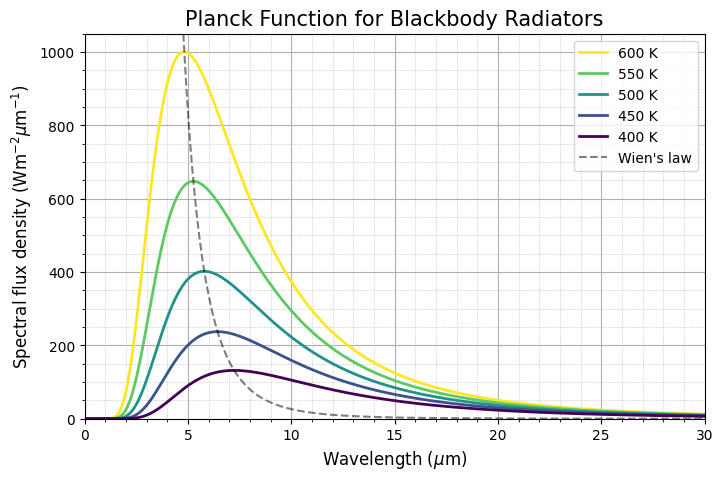

In [2]:
# Planck function graph
num_curves = 5

def planck(wavelengths, temp):
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        return (2 * pi * h * c**2) / (
            wavelengths**5 * (np.exp(h * c / (wavelengths * k * temp)) - 1)
        )

fig, ax = plt.subplots(figsize=[8, 5])
ax.set_xlim(0, 30)
ax.set_ylim(0, 1050)
ax.grid(True, which='major', linestyle='-', linewidth=0.8)
ax.grid(True, which='minor', linestyle=':', linewidth=0.5)
ax.minorticks_on()

wavelengths = np.linspace(0, 30e-6, 1000)
temps = np.linspace(600, 400, num_curves)

colours = plt.cm.viridis(np.linspace(1, 0, num_curves))

if num_curves <= 5:
    label_indices = np.arange(num_curves)
else:
    label_indices = np.linspace(0, num_curves-1, 5, dtype=int)

for n, temp in enumerate(temps):
    
    colour = colours[n]

    if n in label_indices:
        label = f'{round(temp)} K'
    else:
        label = '_nolegend_'
        
    plt.plot(
        wavelengths*1e6, planck(wavelengths, temp)*1e-6, 
        linewidth=2, color=colour, label=label
    )

all_temps = np.linspace(20, 620, 200)
max_wavelengths = Wien / all_temps
peaks = planck(max_wavelengths, all_temps)

plt.plot(
    max_wavelengths*1e6, peaks*1e-6, color='black', 
    linestyle='--', alpha=0.5, label="Wien's law"
)

plt.title('Planck Function for Blackbody Radiators', fontsize=15)
plt.xlabel('Wavelength ($\mu$m)', fontsize=12)
plt.ylabel('Spectral flux density (Wm$^{-2}\mu$m$^{-1}$)', fontsize=12)
plt.legend();
# plt.savefig('Planck_function.png', dpi=150);